<h1><b>Música en datos: análisis de Spotify a partir de su API</br>

<img src="https://www.igroovemusic.com/wp-content/uploads/2022/04/iGroove_Magazin_Blog_Spotify_Algo_Pt2.jpg" alt="Paisaje montañoso" width="950" height="500">


**Tabla de Contenido**

1. [**Introducción**](#intro)
2. [**Objetivos**](#objetivos)
2. [**Limpieza y Ajuste de los Datos**](#limpieza)
4. [**Prueba de Hipótesis**](#hipotesis)
5. [**Bondad de Ajuste**](#bondad)
6. [**Regresión**](#regresion)
7. [**Series de Tiempo**](#serie)
8. [**Referencias Bibliográficas**](#referencias)

<br>

**Enlace del dataset:** https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs?select=spotify_songs.csv

# 1. Introducción <a name="intro"></a>

<img src="https://cristianpoow.com/wp-content/uploads/2025/02/spotify-logo-in-the-center-of-the-screen-with-an-equalizer-in-front1.jpg" alt="Paisaje montañoso" width="950" height="500">

El presente conjunto de datos fue obtenido a través de la API oficial de Spotify y contiene información detallada sobre canciones, artistas y listas de reproducción. Su propósito es permitir el análisis de las características musicales, los patrones de popularidad y las tendencias de consumo dentro de la plataforma.

Cada registro corresponde a una pista musical y reúne tanto metadatos descriptivos (nombre, artista, álbum, género) como atributos cuantitativos derivados del análisis de audio realizado por los algoritmos de Spotify. Entre estos últimos se incluyen métricas relacionadas con la energía, bailabilidad, acústica, valencia, intensidad sonora, ritmo (tempo) y otros parámetros técnicos que reflejan la estructura y estilo de cada canción.

El dataset integra además información contextual proveniente de las listas de reproducción donde las canciones aparecen, junto con su nivel de popularidad dentro de la plataforma, medido en una escala de 0 a 100.

En conjunto, este conjunto de datos ofrece una base sólida para desarrollar análisis exploratorios, modelos predictivos o estudios sobre la relación entre las propiedades musicales y la recepción del público, así como para identificar tendencias entre géneros y subgéneros.

# 2. Objetivos <a name="objetivos"></a>

<img src="https://media.licdn.com/dms/image/v2/D4D12AQHIQt5Ia55akw/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1681921594305?e=2147483647&v=beta&t=XCGWLQ7FJ7XY7O2mjbgaKXP3UtHs-BgS7GpiqMFNGCY" alt="Paisaje montañoso" width="980" height="500">

**<h2>Objetivo general**

Analizar las características musicales y de popularidad de canciones obtenidas desde la API de Spotify con el fin de identificar patrones, relaciones y diferencias significativas entre géneros y subgéneros musicales, así como los factores que influyen en la recepción del público dentro de la plataforma.

**<h2> Objetivos específicos**


*   Determinar si la duración media de las canciones disminuye al pasar del tiempo.
*  Evaluar si las canciones más cortas son más populares que las largas.


# 3. Limpieza y ajuste de los datos <a name="limpieza"></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import t as student_t
from scipy.stats import chi2

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/UNIVERSIDAD/ESTADISTICA II/Proyecto/spotify_songs.csv')
df = df.drop(columns=['track_id', 'track_album_id', 'playlist_id'])
df["track_album_release_date"] = pd.to_datetime(df["track_album_release_date"], errors="coerce")
df.head(5)

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,Memories - Dillon Francis Remix,Maroon 5,67,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,All the Time - Don Diablo Remix,Zara Larsson,70,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_name                32828 non-null  object        
 1   track_artist              32828 non-null  object        
 2   track_popularity          32833 non-null  int64         
 3   track_album_name          32828 non-null  object        
 4   track_album_release_date  30947 non-null  datetime64[ns]
 5   playlist_name             32833 non-null  object        
 6   playlist_genre            32833 non-null  object        
 7   playlist_subgenre         32833 non-null  object        
 8   danceability              32833 non-null  float64       
 9   energy                    32833 non-null  float64       
 10  key                       32833 non-null  int64         
 11  loudness                  32833 non-null  float64       
 12  mode              

## Ajuste de datos para Prueba de Hipótesis

In [ ]:
# Filtrar las canciones desde 2019 en adelante pqra la prueba de hipotesis de una variable
df_2019 = df[df["track_album_release_date"].dt.year >= 2019]

# Grupo 1: duración > 210000 ms
grupo_mayor = df_2019[df_2019["duration_ms"] > 210000]

# Grupo 2: duración <= 210000 ms
grupo_menor_igual = df_2019[df_2019["duration_ms"] <= 210000]
menor = grupo_menor_igual.sample(n=3128)


# Calcular popularidad media en ambos grupos
media_mayor = grupo_mayor["track_popularity"].mean()
media_menor_igual = menor["track_popularity"].mean()

media_mayor,media_menor_igual

(np.float64(49.94693094629156), np.float64(51.262787723785166))

## Ajuste de datos para Bondad de Ajuste

In [ ]:
f_obs = (
    df[df['playlist_genre'].isin(['pop', 'rap', 'rock', 'latin', 'r&b', 'edm'])]
    .groupby('playlist_genre')['track_popularity']
    .mean()
    .round(2)
    .reset_index()
)

poblacion = len(df)

num_categorias = df['playlist_genre'].nunique()

array_obs= f_obs['track_popularity'].tolist()
array_obs=np.array(array_obs)

array_obs

array([34.83, 47.03, 47.74, 41.22, 43.22, 41.73])

In [ ]:
f_obs2 = (
    df[df['playlist_genre'].isin(['pop', 'rap', 'rock', 'latin', 'r&b', 'edm'])]
    .groupby('playlist_genre')['acousticness']
    .mean()
    .round(4)
    .reset_index()
)

poblacion2 = len(df)

num_categorias2 = df['playlist_genre'].nunique()

array_obs2= f_obs2['acousticness'].tolist()
array_obs2=np.array(array_obs2)

array_obs2

array([0.0815, 0.2109, 0.1708, 0.2599, 0.1925, 0.1452])

# 4. Prueba de Hipótesis <a name="hipotesis"></a>

## Prueba de hipótesis de una variable

Varios trabajos y reportes señalan una tendencia reciente a la reducción de la duración de las canciones en la era del streaming, atribuida a incentivos económicos y a la economía de la atención propia de plataformas como Spotify y a fenómenos virales tipo TikTok. El artículo académico de revisión en SAGE argumenta que el streaming ha contribuido a que las pistas sean más cortas y la experiencia musical más fragmentada.
[[1](#ref1)]

Reportajes y análisis muestran que entre 2013 y 2018 la duración media de los éxitos cayó de ~3:50 a ~3:30, lo cual motiva tomar 3:30 como umbral para evaluar cambios recientes.
[[2](#ref2)]

Por estas razones, proponemos contrastar si en nuestro conjunto de datos, las canciones publicadas a partir de 2019 presentan una duración media menor a 3:30 minutos que equivalen a 210 000 ms.

<br>

$H_o​ : \mu = 210000$  <br><br>
$H_a : \mu < 210000$  <br><br>


### Función prueba de hipótesis una variable

In [ ]:
# FUNCION DE PRUEBA DE HIPOTESIS CON VARIANZA DESCONOCIDA

# x = media muestral (𝑥̄)
# mp = media poblacional hipotética (μ₀)
# s = desviación estándar muestral
# n = tamaño de la muestra
# alpha = nivel de significancia (α)
# mp_alt = media alternativa (β)
# alpha_alt = nivel de significancia alterno
# tipo  : tipo de prueba 'bilateral', 'mayor' o 'menor'

def prueba_desconocida(x, mp, s, n, tipo, alpha, mp_alt, alpha_alt):

    if n <= 1:
        print("Error: La muestra debe tener más de 1 dato.")
        return

    df = n - 1  # grados de libertad

    # Estadístico t
    t = (x - mp) / (s / (n ** 0.5))
    print(f" - Estadístico t: {t:.4f}")

    # Decisión según el tipo de prueba
    if tipo == 'bilateral':
        t_crit = student_t.ppf(1 - alpha/2, df)
        print()
        print(f" - Región de rechazo: t < -{t_crit:.4f} & t > {t_crit:.4f}")
        print()
        decision = "Rechazar H0" if abs(t) > t_crit else "Aceptar H0"
        p_valor = 2 * (1 - norm.cdf(abs(t)))

    elif tipo == 'mayor':
        t_crit = student_t.ppf(1 - alpha, df)
        print()
        print(f" - Región de rechazo: t > {t_crit:.4f}")
        print()
        decision = "Rechazar H0" if t > t_crit else "Aceptar H0"
        p_valor = 1 - norm.cdf(t)

    elif tipo == 'menor':
        t_crit = student_t.ppf(alpha, df)
        print(f" - Región de rechazo: t < {t_crit:.4f}")
        decision = "Rechazar H0" if t < t_crit else "Aceptar H0"
        p_valor = norm.cdf(t)

    else:
        print("Error: tipo de prueba no válido. Usa 'bilateral', 'mayor' o 'menor'.")
        return
    print(f" - Decisión según t: {decision}")
    print(f" - p-valor: {p_valor:.10f}  |  alpha: {alpha:.10f}")
    print(f" - Decisión según p-valor: {'Rechazar H0' if p_valor < alpha else 'Aceptar H0'}")


    # --- Calculo del nuevo z con el alpha alternativo ---
    if alpha_alt is not None:
        t_crit = 0
        if tipo == 'bilateral':
            t_crit = student_t.ppf(1 - alpha_alt/2, df)
        elif tipo == 'mayor':
            t_crit = student_t.ppf(1 - alpha_alt, df)
        elif tipo == 'menor':
            t_crit = student_t.ppf(alpha_alt, df)

    # --- Cálculo del error tipo II (si se da media alternativa) ---
    if mp_alt is not None:
        se = s / (n ** 0.5)
        if tipo == 'bilateral':
            beta = norm.cdf(t_crit - (mp_alt - mp)/se) - norm.cdf(-t_crit - (mp_alt - mp)/se)
            print(f" - Error tipo II (β) para media alternativa {mp_alt}: {beta:.4f}")
            print()
        elif tipo == 'mayor':
            beta = norm.cdf(t_crit - (mp_alt - mp)/se)
            print(f" - Error tipo II (β) para media alternativa {mp_alt}: {beta:.4f}")
            print()
        elif tipo == 'menor':
            beta = 1 - norm.cdf(t_crit - (mp_alt - mp)/se)
            print(f" - Error tipo II (β) para media alternativa {mp_alt}: {beta:.4f}")
            print()


    # --- Cálculo de Intervalos de confianza ---
    if tipo == 'bilateral':
        # Intervalo de aceptación
        ic_inf = x - s * t_crit / (n ** 0.5)
        ic_sup = x + s * t_crit / (n ** 0.5)
        print()
        print(f" - Intervalo de aceptación: {ic_inf:.4f} ≤ μ ≤ {ic_sup:.4f}")

    elif tipo == 'mayor':
        # Intervalo de aceptación
        ic_sup = x + s * t_crit / (n ** 0.5)
        print()
        print(f" - Intervalo de aceptación: μ ≤ {ic_sup:.4f}")

    elif tipo == 'menor':
        # Intervalo de aceptación
        ic_inf = x - s * t_crit / (n ** 0.5)
        print(f" - Intervalo de aceptación: {ic_inf:.4f} ≤ μ")

In [ ]:
media = df_2019["duration_ms"].mean()
print("Media:", media)

desviacion = df_2019["duration_ms"].std()
print("Desviación estándar:", desviacion)

poblacion = len(df_2019["duration_ms"])
print("Cantidad de datos:", poblacion)

Media: 197699.03649635037
Desviación estándar: 44754.76362855147
Cantidad de datos: 9864


### Cálculo y análisis de la prueba de hipótesis

In [ ]:
x = media
mp = 210000
s = desviacion
n = poblacion
tipo = 'menor'
alpha = 0.05
alpha_alt = None
mp_alt = None
resultado = prueba_desconocida(x, mp, s, n, tipo, alpha, mp_alt, alpha_alt)

 - Estadístico t: -27.2977
 - Región de rechazo: t < -1.6450
 - Decisión según t: Rechazar H0
 - p-valor: 0.0000000000  |  alpha: 0.0500000000
 - Decisión según p-valor: Rechazar H0
 - Intervalo de aceptación: 198440.3139 ≤ μ


El resultado de la prueba muestra un estadístico t altamente significativo, con un p-valor prácticamente nulo, lo que indica que la duración promedio de las canciones desde 2018 es significativamente menor que 3 minutos y 30 segundos. El valor promedio obtenido (197.699 ms ≈ 3 min 17 s) se encuentra por debajo del umbral de aceptación y dentro del rango reportado por los estudios internacionales, que identifican una media global entre 3:10 y 3:20 minutos para la música popular reciente.


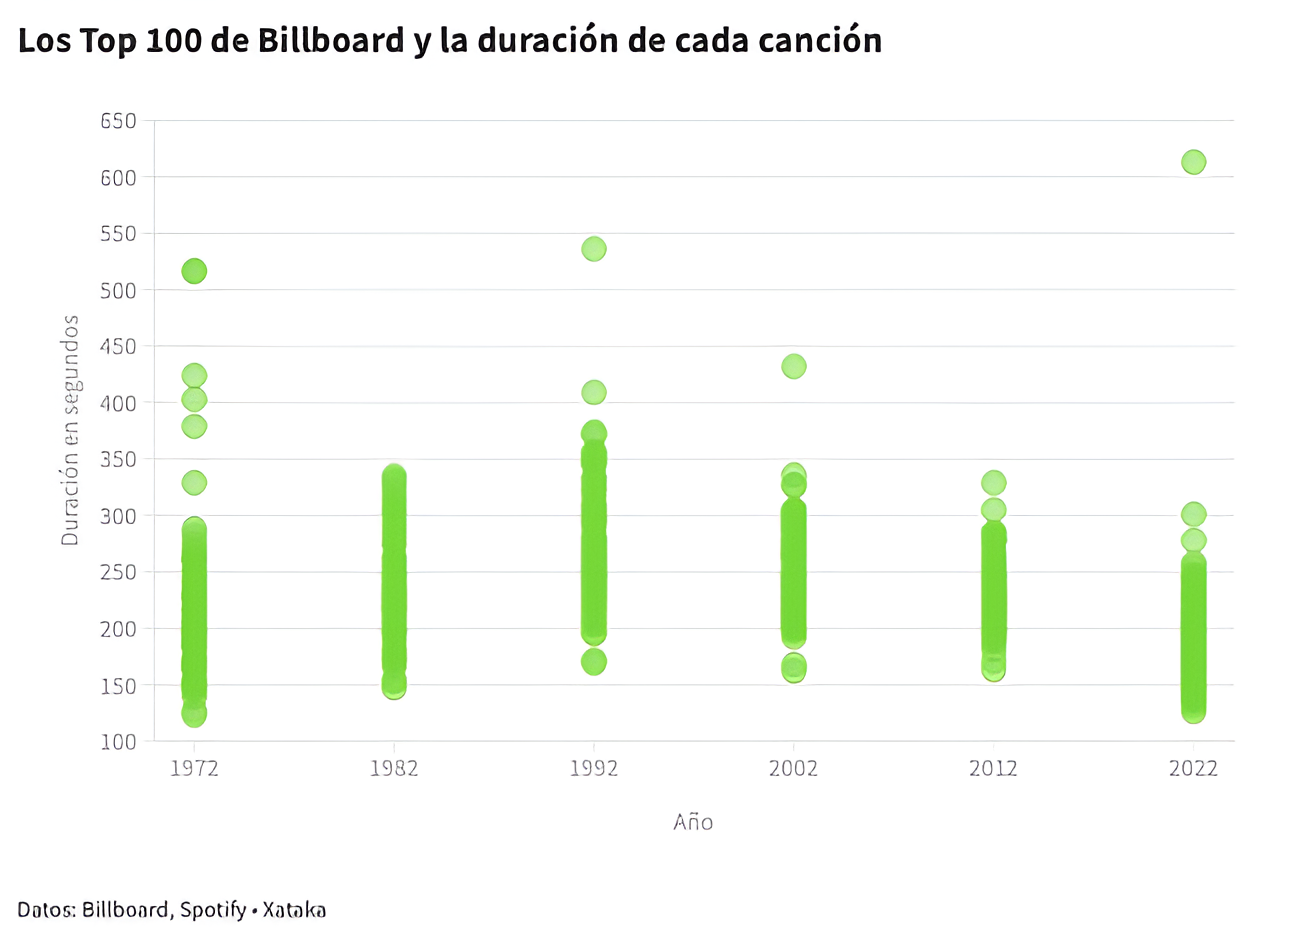


Esto no es casualidad y tiene que ver con cómo el paso a la música por streaming ha cambiado los incentivos para los músicos y toda su industria. Por ejemplo, con el pago por reproducción, Spotify cuenta como reproducción cada escucha superior a los 30 segundos. Luego están los algoritmos de las plataformas, que premian las canciones que son escuchadas en su totalidad, una forma de tener a la gente ocupada escuchando música con un menor número de saltos, lo que deriva en menos royalties que pagar, la clave que decide si Spotify es rentable como empresa o no.

Además, los estribillos suelen llegar más temprano, fruto de nuestra poca capacidad de atención y lo fácil que nos resulta cambiar de estímulo. Hay otra explicación para el auge del estribillo temprano, es lo que suele acabar en TikTok, un actor muy importante para el descubrimiento musical, pero no por reproducir canciones completas, sino solo los fragmentos más pegadizos e icónicos, como recoge un análisis de la propia Billboard, por ende, será más fácil querer compartirlos si se han escuchado antes, para lo cual han de llegar temprano o corren el riesgo de no llegar a ser escuchados.[[3](#ref3)]

## Prueba de hipótesis de dos variables

Nuestro análisis anterior confirmó que, efectivamente, las canciones publicadas a partir de 2018 presentan una duración media significativamente menor a 3:30 minutos , un fenómeno ampliamente documentado que se atribuye a los incentivos económicos del streaming y la economía de la atención en plataformas digitales.

Este acortamiento de las canciones no es un fin en sí mismo, sino un medio para un objetivo comercial más amplio como maximizar la popularidad y el alcance. Como se discutió previamente, los algoritmos de plataformas como Spotify y TikTok premian la retención de atención y la capacidad de generar repeticiones, favoreciendo estructuras musicales donde el estribillo llega antes.

Si esta estrategia es efectiva, deberíamos observar que las canciones más cortas no solo existen, sino que triunfan. Es decir, deberían ser más populares.

<br>

- $H_0​ : \mu_1 - \mu_2 = 0$ <br><br>
- $H_a​ : \mu_1 - \mu_2 > 0$ <br><br>

Donde:
- $ \mu_1: $  Popularidad media entre canciones cortas < 210,000 ms
-  $ \mu_2: $  Popularidad media entre canciones largas ≥ 210,000 ms

### Función de prueba de hipótesis de dos variables

In [ ]:
# FUNCION DE PRUEBA DE HIPOTESIS CON VARIANZA DESCONOCIDA

# x = media muestral (𝑥̄_1，𝑥̄_2)
# mp = media poblacional hipotética (μ_1, μ_2)
# s = desviación estándar (σ)
# n = tamaño de la muestra
# alpha = nivel de significancia (α)
# mp_alt = media alternativa (β)

def prueba_desconocida_dos(x1, x2, s1, s2, n1, n2, alpha, tipo, caso):

  if n1 <= 1 or n2 <= 1:
        print("Error: La muestra debe tener más de 1 dato.")
        return


  # Calculo Estadistico T si las varianzas son desconocidas pero iguales
  if caso == 'igual':
    s_p = np.sqrt( ((n1 - 1) * (s1**2) + (n2 - 1) * (s2**2)) / (n1 + n2 - 2) )
    t = (x1 - x2) / (s_p * np.sqrt(1/n1 + 1/n2))
    # grados de libertad
    v = n1 + n2 - 2
    print(f" - Estadístico T: {t:.4f}")

  # Calculo Estadistico T si las varianzas son desconocidas pero diferentes
  if caso == 'diferentes':
    t = (x1 - x2) / np.sqrt((s1**2 / n1) + (s2**2 / n2))
    # grados de libertad
    v = int(round(( (s1**2 / n1) + (s2**2 / n2) )**2 / ( ( (s1**2 / n1)**2 / (n1 + 1) ) + ( (s2**2 / n2)**2 / (n2 + 1 ) ) )))
    print(f"- Estadístico T: {t:.4f}")
    print(f"- Grados de libertad: {v:.4f}")


  # Decisión según el tipo de prueba
  if tipo == 'bilateral':

    t_crit = student_t.ppf(1 - alpha/2, v)

    # Región de rechazo de alpha
    print(f" - Región de rechazo: -{t_crit:.4f} < T > {t_crit:.4f}")

    # Decision si se rechaza o no Ho
    decision = "Rechazar H0" if abs(t) > t_crit else "Aceptar H0"

    # P - valor
    p_valor = 2 * (1 - norm.cdf(abs(t)))


  elif tipo == 'mayor':

    t_crit = student_t.ppf(1 - alpha, v)

    # Región de rechazo de alpha
    print(f"- Región de rechazo: {t_crit:.4f} < T")

    # Decision si se rechaza o no Ho
    decision = "Rechazar H0" if t > t_crit else "Aceptar H0"

    # P - valor
    p_valor = 1 - norm.cdf(t)


  elif tipo == 'menor':

    t_crit = student_t.ppf(alpha, v)

    # Región de rechazo de alpha
    print(f" - Región de rechazo: T > {t_crit:.4f}")

    # Decision si se rechaza o no Ho
    decision = "Rechazar H0" if t < t_crit else "Aceptar H0"

    # P - valor
    p_valor = norm.cdf(t)


  else:
    print("Error: tipo de prueba no válido. Usa 'bilateral', 'mayor' o 'menor'.")
    return

  # Decisiones a partir de los criterios
  print(f"- Decisión según T: {decision}")
  print(f"- P-valor: {p_valor:.4f}")
  print(f"- Decisión según p-valor: {'Rechazar H0' if p_valor < alpha else 'Aceptar H0'} para alpha: {alpha}")



  # Intervalos de confianza
  raiz = np.sqrt((s1**2 / n1) + (s2**2 / n2))

  if tipo == 'bilateral':
    intervalo_n = (x1 - x2) - t_crit * raiz
    intervalo_p = (x1 - x2) + t_crit * raiz
    print(f"\n - Intervalo de confianza: {intervalo_n:.4f} ≤ μ_1 - μ_2 ≤ {intervalo_p:.4f}")

  elif tipo == 'mayor':
    intervalo_p = (x1 - x2) + t_crit * raiz
    print(f"- Intervalo de confianza: μ_1 - μ_2 ≤ {intervalo_p:.4f}")

  elif tipo == 'menor':
    intervalo_n = (x1 - x2) - t_crit * raiz
    print(f"\n - Intervalo de confianza: {intervalo_n:.4f} ≤ μ_1 - μ_2")

In [ ]:
media2 = grupo_mayor["track_popularity"].mean()
print("Media ≥ 210,000 ms:", media2)
media3 = menor["track_popularity"].mean()
print("Media < 210,000 ms:", media3)

desviacion2 = grupo_mayor["track_popularity"].std()
print("Desviación estándar≥ 210,000 ms:", desviacion2)
desviacion3 = menor["track_popularity"].std()
print("Desviación estándar < 210,000 ms:", desviacion3)

poblacion2 = len(grupo_mayor["track_popularity"])
print("Cantidad de datos ≥ 210,000 ms:", poblacion2)
poblacion3 = len(menor["track_popularity"])
print("Cantidad de datos < 210,000 ms:", poblacion3)

Media ≥ 210,000 ms: 49.94693094629156
Media < 210,000 ms: 51.262787723785166
Desviación estándar≥ 210,000 ms: 21.745373525401277
Desviación estándar < 210,000 ms: 20.33351585737639
Cantidad de datos ≥ 210,000 ms: 3128
Cantidad de datos < 210,000 ms: 3128


### Cálculo y análisis de la prueba de hipótesis

In [ ]:
x1=media2
x2=media3
s1=desviacion2
s2=desviacion3
n1=poblacion2
n2=poblacion3
alpha = 0.05
tipo = 'mayor'
caso = 'diferentes'
prueba_desconocida_dos(x1, x2, s1, s2, n1, n2, alpha, tipo, caso)

- Estadístico T: -3.1945
- Grados de libertad: 6229.0000
- Región de rechazo: 1.6451 < T
- Decisión según T: Aceptar H0
- P-valor: 0.9993
- Decisión según p-valor: Aceptar H0 para alpha: 0.05
- Intervalo de confianza: μ_1 - μ_2 ≤ -0.8243


Los resultados de la prueba de hipótesis entre la duración y la popularidad de las canciones indican que, aunque las pistas más cortas muestran una popularidad media ligeramente superior (51.26 frente a 49.95 puntos), esta diferencia no es estadísticamente significativa. El valor obtenido para el estadístico t=−3.19, junto con un p-valor de 0.9993, lleva a aceptar la hipótesis nula, lo que significa que no existen pruebas suficientes para afirmar que las canciones más cortas sean más populares que las largas.

En otras palabras, el análisis no confirma una relación directa entre menor duración y mayor éxito. Aunque la reducción de las canciones es una tendencia real, no garantiza que se vuelva más popular.

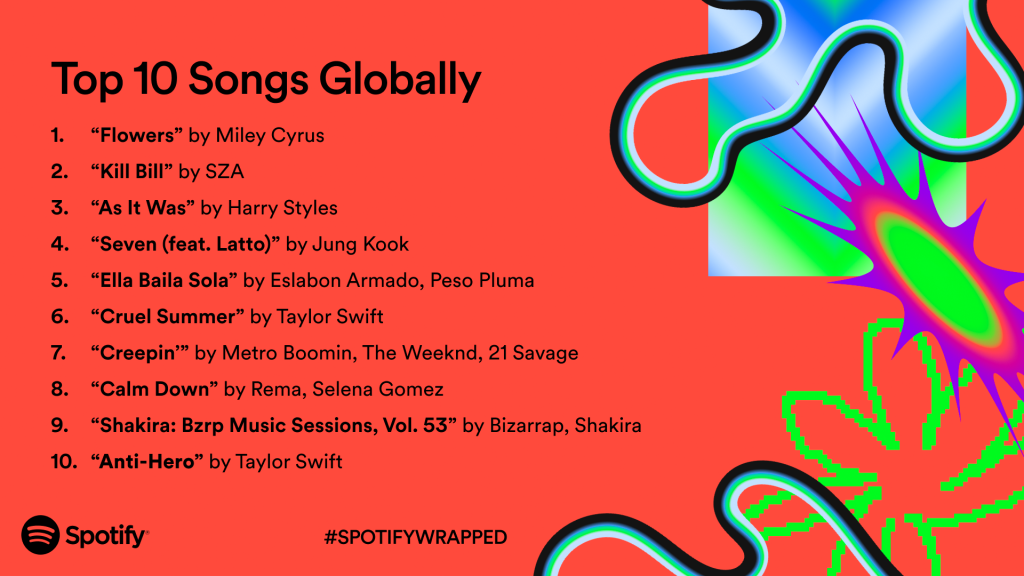

Esto se debe a que la popularidad en plataformas como Spotify depende de una compleja combinación de factores: la presencia del artista, la publicidad, el género, o incluso el contexto social en que una canción se vuelve viral(si el artista esta en una polémica). Así, una canción corta puede tener más potencial para retener la atención del oyente, pero no necesariamente logra destacar en un entorno altamente competitivo donde el algoritmo prioriza otros elementos de engagement.

Por su parte, las canciones más largas no muestran una desventaja significativa en términos de popularidad. Es probable que, pese a su mayor duración, mantengan niveles similares de éxito cuando provienen de artistas consolidados o de géneros donde la extensión es parte de la identidad musical (por ejemplo, el rock o la electrónica). Esto explicaría que, en promedio, la diferencia observada en la popularidad entre canciones cortas y largas sea pequeña y estadísticamente irrelevante.

En conjunto, estos resultados coinciden con la literatura [[1](#ref1)] [[3](#ref3)] el streaming ha transformado la forma en que se produce y consume música, incentivando canciones más breves y directas, pero el éxito no depende únicamente de la duración, sino de la capacidad de conectar con el público y de adaptarse al ecosistema digital. La duración, más que un factor determinante, actúa como una estrategia dentro de un modelo de consumo orientado a la atención y la repetición.

# 5. Bondad de Ajuste <a name="bondad"></a>

## Función de ajuste de bondad simple

In [ ]:
# Categorias - k
# Poblacion total - n
# Frecuencia observada - f_o
# Frecuencia esperada - f_e
# Nivel de significancia - alpha

def bondad(k, n, f_o, f_e, alpha):

    # Cálculo de grados de libertad
    v = k - 1

    # Estadístico de prueba chi-cuadrado
    x_2 = np.sum((f_o - f_e)**2 / f_e)

    p_valor = 1 - chi2.cdf(x_2, v)
    # Región de rechazo
    x_critic = chi2.ppf(1 - alpha, v)

    print(f" - Valor de X²: {x_2:.4f}")
    print(f" - Valor crítico X²({alpha:.2f}, {v} gl): {x_critic:.2f}")


    # Decisión
    if x_2 > x_critic:
      print(" - Se rechaza la hipotesis nula")
    else:
      print(" - Se acepta la hipotesis nula")


## Bondad de ajuste según Popularidad por Género Musical

In [ ]:
k = num_categorias
n = poblacion
f_o = array_obs
f_e = [30.68,41.45,45.91,35.93,41.85,39.69]
alpha = 0.05

bondad(k, n, f_o,f_e, alpha)

 - Valor de X²: 2.3140
 - Valor crítico X²(0.05, 5 gl): 11.07
 - Se acepta la hipotesis nula


En esta sección se aplicó una prueba de bondad de ajuste para contrastar si la popularidad promedio observada por género musical en nuestro conjunto de datos se ajusta a la distribución esperada descrita en DV2 Final Project: Spotify [[4](#ref4)]. Dicho estudio, basado en datos de la API pública de Spotify, reporta medias de popularidad por género que reflejan el comportamiento de la plataforma.

El objetivo fue evaluar si la distribución de popularidad en nuestro dataset mantiene el mismo patrón general o si presenta desviaciones significativas.

* Hipótesis nula ($H_0$):
La distribución de la popularidad promedio por género en Spotify no difiere significativamente de la distribución esperada según el estudio de referencia.


* Hipótesis alternativa ($H_a$):
La distribución de la popularidad promedio por género en Spotify difere significativamente de la distribución esperada.

Los resultados de la prueba indican un valor de $\chi^2$= 2.314, muy inferior al valor crítico de 11.07. En consecuencia, se acepta la hipótesis nula, lo cual implica que no existen diferencias estadísticamente significativas entre las frecuencias observadas y las esperadas.

El gráfico comparativo refuerza este resultado aunque se observan pequeñas variaciones estas diferencias no son lo suficientemente amplias como para considerarse significativas.


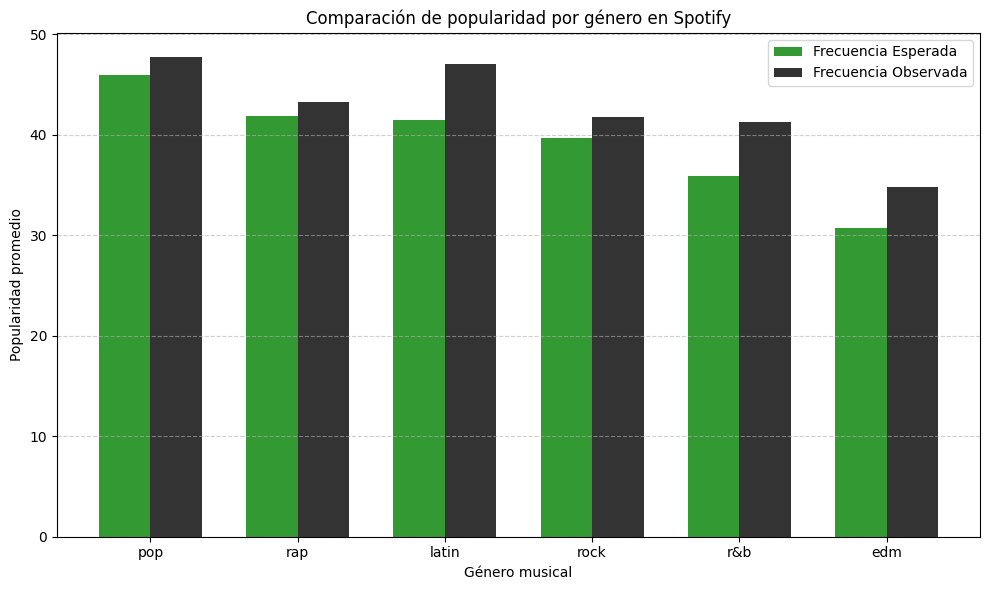

Los géneros pop, rap y latino destacan porque suelen estar más integrados en las dinámicas actuales del consumo musical digital. Esto se debe a su fuerte presencia en playlists, su capacidad de adaptarse a tendencias virales en redes sociales como TikTok y su frecuencia en colaboraciones con artistas reconocidos, lo que amplía su alcance.


## Bondad de ajuste según Grado Acústico

In [ ]:
k = num_categorias2
n = poblacion2
f_o = array_obs2
f_e = [0.0769,0.2127,0.1721,0.2641,0.1966,0.1475]
alpha = 0.05

bondad(k, n, f_o,f_e, alpha)

 - Valor de X²: 0.0005
 - Valor crítico X²(0.05, 5 gl): 11.07
 - Se acepta la hipotesis nula


Añadido al anterior análisis, se aplicó al promedio de la acústica por genéro.

En términos prácticos, la acústica es una medida que refleja qué tan “orgánica” o “natural” es una canción, es decir, la proporción de sonidos no electrónicos o grabados en entornos reales. Valores altos implican la presencia de instrumentos reales o grabaciones en vivo, mientras que valores bajos indican una mayor dependencia de la producción digital o sintetizadores.

* Hipótesis nula ($H_0$):
La distribución de la acústica promedio por género en Spotify no difiere significativamente de la distribución esperada según el estudio de referencia.


* Hipótesis alternativa ($H_a$):
La distribución de la acústica promedio por género en Spotify difere significativamente de la distribución esperada.

El análisis revelo un resultado estadísticamente consistente con el modelo teórico: el valor de $\chi^2$ = 0.0005 es muy inferior al valor crítico de 11.07, por lo que se acepta la hipótesis nula. Esto indica que la distribución observada de la acústica entre géneros no difiere significativamente de la esperada según el estudio de referencia [[4](#ref4)]

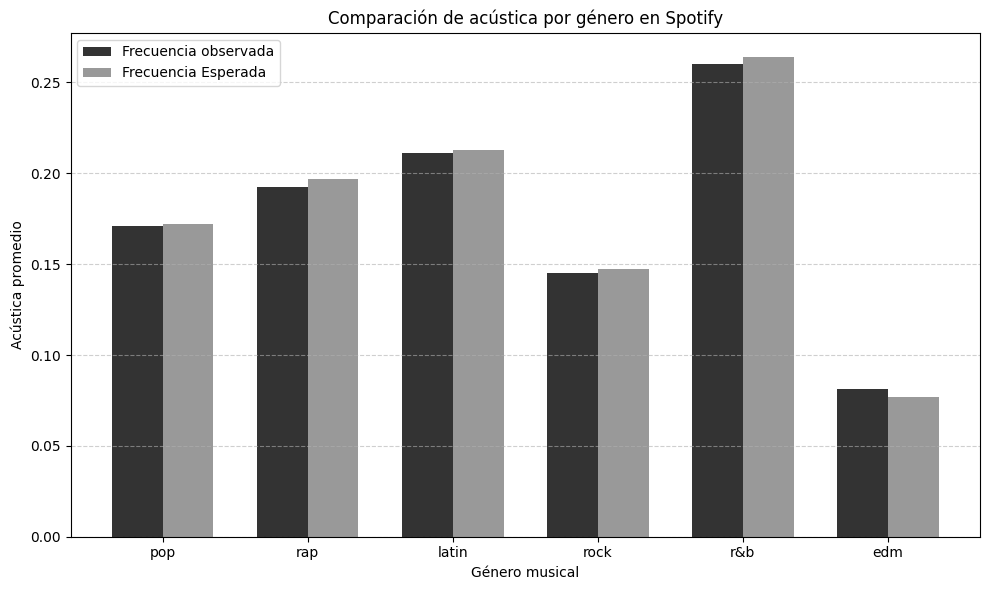

En el gráfico se observa que géneros como R&B y Latin tienden a presentar niveles acústicos más altos, lo cual coincide con su tendencia a incluir instrumentos reales (guitarras, percusión o voces). En contraste, géneros como EDM (electronic dance music) exhiben los valores más bajos, coherente con su naturaleza completamente digital y su orientación a la pista de baile.

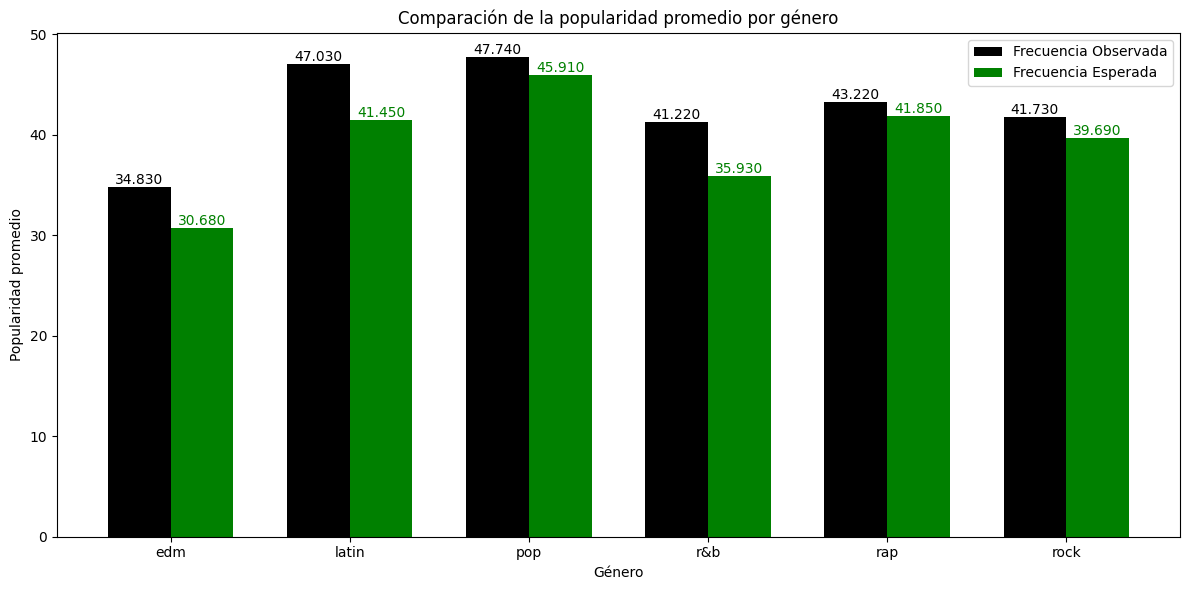

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f_esperada = [30.68,41.45,45.91,35.93,41.85,39.69]
f_observada =[34.83, 47.03, 47.74, 41.22, 43.22, 41.73]

genres = ["edm","latin","pop","r&b","rap","rock"]

x = np.arange(len(genres))
width = 0.35

plt.figure(figsize=(12,6))

# Barras
bars1 = plt.bar(x - width/2, f_observada, width, label="Frecuencia Observada", color="black")
bars2 = plt.bar(x + width/2, f_esperada, width, label="Frecuencia Esperada", color="green")

# Etiquetas encima de cada barra
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}",
             ha='center', va='bottom', color="black", fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}",
             ha='center', va='bottom', color="green", fontsize=10)

plt.xticks(x, genres)
plt.ylabel("Popularidad promedio")
plt.xlabel("Género")
plt.title("Comparación de la popularidad promedio por género")
plt.legend()
plt.tight_layout()
plt.show()


# 8. Referencias Bibliograficas <a name="referencias"></a>


[1] <a name="ref1"></a> [Streaming’s Effects on Music
Culture: Old Anxieties and
New Simplifications](https://journals.sagepub.com/doi/pdf/10.1177/17499755211019974?)

[2] <a name="ref2"></a> [The economics of streaming is making songs shorter](https://qz.com/1519823/is-spotify-making-songs-shorter?)

[3] <a name="ref3"></a>  [Hemos mirado los datos de los últimos 30 años para saber si la música se está tiktokizando. La respuesta es rotunda](https://www.xataka.com/musica/hemos-mirado-datos-ultimos-30-anos-para-saber-musica-se-esta-tiktokizando-respuesta-rotunda)

[4] <a name="ref4"></a> [DV2 Final Project: Spotify
](https://lisahlmsch.github.io/assets/Spotify.pdf?)
